In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import networkx as nx

In [ ]:
# Load the graph and get the graph adjacency matrix
G = nx.read_edgelist("N40_y2.4.edgelist", nodetype=int)
A = nx.to_numpy_array(G, nodelist=sorted(G.nodes()))
N = A.shape[0]
k = A.sum(axis=1)
k_mean = k.mean()

In [ ]:
def laser_ode(t, y, A, g, Gamma, kappa, gamma_p, sigma0, J, Delta, r):
    Nloc = A.shape[0]
    ReE, ImE = y[:Nloc], y[Nloc:2*Nloc]
    sigma, E = y[2*Nloc:3*Nloc], ReE + 1j*ImE
    dE = -(kappa + 1j*Delta)*E + (g/Gamma)*sigma*E + 1j*J*(A @ E) + r
    ds = gamma_p*(sigma0 - sigma) - 4*(g/Gamma)*sigma*np.abs(E)**2
    return np.concatenate([dE.real, dE.imag, ds])

def solve_fields(J, Delta, r, sigma0_vec, params):
    g, Gamma, kappa, gamma_p, sigma0 = params
    y0 = np.concatenate([E0.real, E0.imag, sigma0_vec])
    sol = solve_ivp(laser_ode, (0, T), y0, t_eval=t_eval, method='BDF',
                    args=(A, g, Gamma, kappa, gamma_p, sigma0, J, Delta, r),
                    rtol=1e-6, atol=1e-9)
    E_t = sol.y[:N] + 1j * sol.y[N:2*N]
    sigma_t = sol.y[2*N:3*N]
    return sol.t, E_t, np.abs(E_t), np.abs(E_t)**2, sigma_t

def mean_curves(E_t, sigma_t, k):
    E2 = np.abs(E_t)**2
    N = E_t.shape[0]
    I_mean = E2.mean(axis=0)
    Z_mean = sigma_t.mean(axis=0)
    k_mean = np.mean(k)
    norm = 1 / (N * k_mean)
    I_mean_k = norm * np.sum(k[:, None] * E2, axis=0)
    Z_mean_k = norm * np.sum(k[:, None] * sigma_t, axis=0)
    return I_mean_k, Z_mean_k

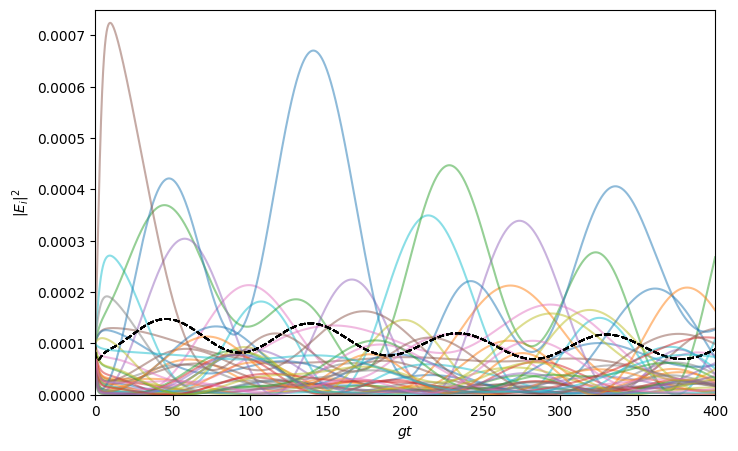

In [ ]:
SEED = 25
rng = np.random.default_rng(SEED)

# Initial conditions
sigma0 = np.clip(rng.normal(0.1875, 0.001, N), 0, 1)
params = (0.4, 0.6, 0.125, 0.175, sigma0)  # g, Gamma, kappa, gamma_p, sigma0
T, Nt = 1000, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.1, 0.2, N), -0.5, 0.5)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_fields(J=0.002, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, E2_mod[i], alpha=0.5); plt.plot(params[0]*t, E2_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$|E_i|^2$'); plt.title('');
plt.xlim(0, 400)
plt.ylim(0, 0.00075)
plt.show()

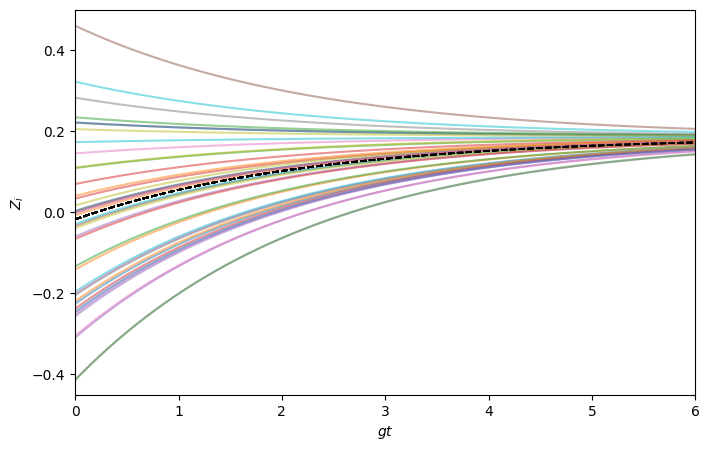

In [ ]:
SEED = 25
rng = np.random.default_rng(SEED)

sigma0 = np.clip(rng.normal(0.1875, 0.001, N), 0, 1)
params = (0.4, 0.6, 0.125, 0.175, sigma0)
T, Nt = 1000, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.1, 0.2, N), -0.5, 0.5)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_fields(J=0.002, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, sigma_t[i], alpha=0.5); plt.plot(params[0]*t, Z_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$Z_i$'); plt.title('');
plt.xlim(0, 6)
plt.ylim(-0.45, 0.5)
plt.show()

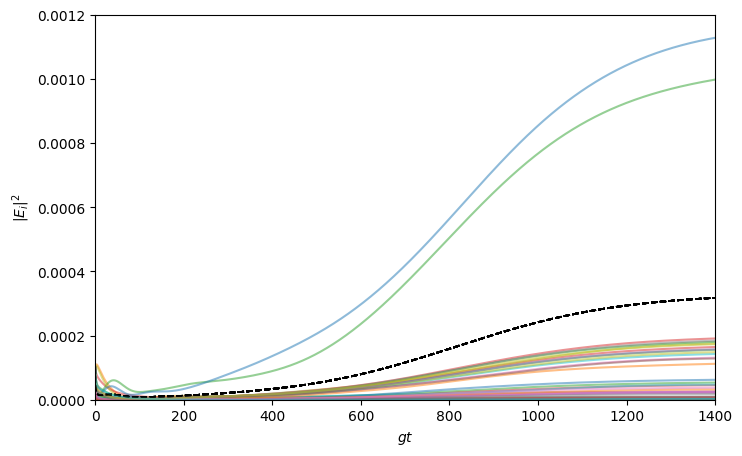

In [ ]:
SEED = 35
rng = np.random.default_rng(SEED)

sigma0 = np.clip(rng.normal(0.181, 0.001, N), 0, 1)
params = (0.4, 0.6, 0.125, 0.175, sigma0)
T, Nt = 40000, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.1, 0.2, N), -0.5, 0.5)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_fields(J=0.002+0.001j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, E2_mod[i], alpha=0.5); plt.plot(params[0]*t, E2_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$|E_i|^2$'); plt.title('');
plt.xlim(0, 1400)
plt.ylim(0, 0.0012)
plt.show()

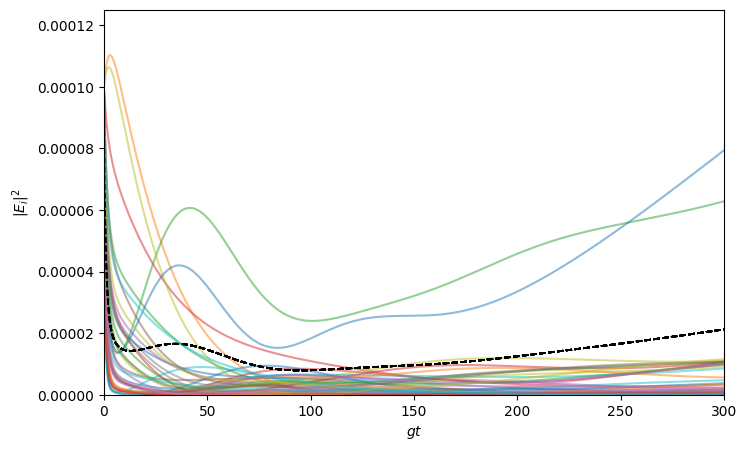

In [ ]:
SEED = 35
rng = np.random.default_rng(SEED)

sigma0 = np.clip(rng.normal(0.181, 0.001, N), 0, 1)
params = (0.4, 0.6, 0.125, 0.175, sigma0)
T, Nt = 40000, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.1, 0.2, N), -0.5, 0.5)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_fields(J=0.002+0.001j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, E2_mod[i], alpha=0.5); plt.plot(params[0]*t, E2_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$|E_i|^2$'); plt.title('');
plt.xlim(0, 300)
plt.ylim(0, 0.000125)
plt.show()

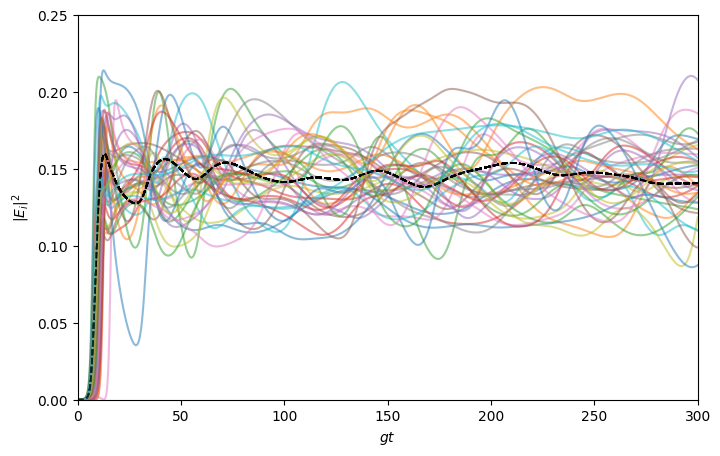

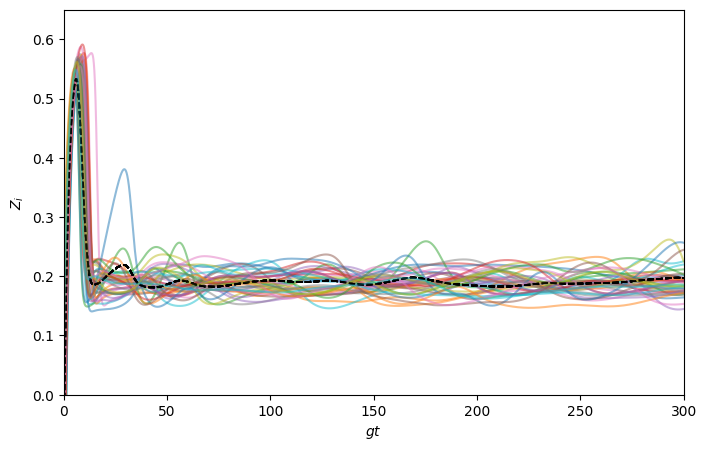

In [ ]:
SEED = 35
rng = np.random.default_rng(SEED)

sigma0 = np.clip(rng.normal(0.6, 0.01, N), 0, 1)
params = (0.4, 0.6, 0.05/0.4, 0.07/0.4, sigma0)
T, Nt = 10000, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.1, 0.2, N), -0.5, 0.5)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_fields(J=0.01+0.001j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, E2_mod[i], alpha=0.5); plt.plot(params[0]*t, E2_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$|E_i|^2$'); plt.title('');
plt.xlim(0, 300)
plt.ylim(0, 0.25)
plt.show()

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_fields(J=0.01+0.001j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, sigma_t[i], alpha=0.5); plt.plot(params[0]*t, Z_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$Z_i$'); plt.title('');
plt.xlim(0, 300)
plt.ylim(0.0, 0.65)
plt.show()

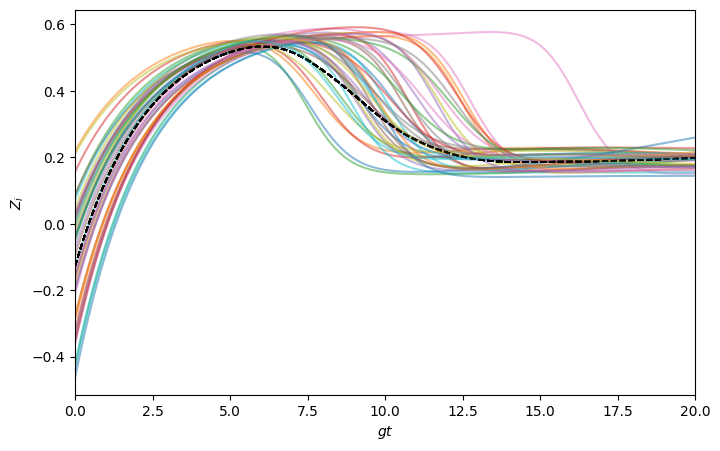

In [ ]:
SEED = 35
rng = np.random.default_rng(SEED)

sigma0 = np.clip(rng.normal(0.6, 0.01, N), 0, 1)
params = (0.4, 0.6, 0.05/0.4, 0.07/0.4, sigma0)
T, Nt = 10000, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.1, 0.2, N), -0.5, 0.5)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_fields(J=0.01+0.001j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, sigma_t[i], alpha=0.5); plt.plot(params[0]*t, Z_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$Z_i$'); plt.title('');
plt.xlim(0, 20)
plt.show()

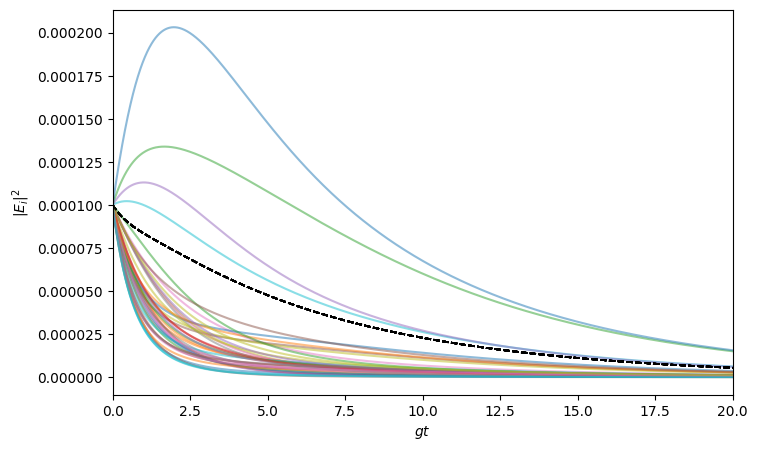

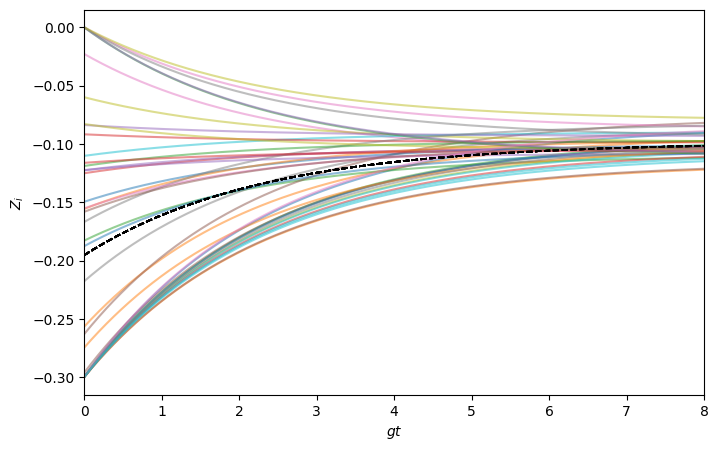

In [ ]:
SEED = 30
rng = np.random.default_rng(SEED)

sigma0 = np.clip(rng.normal(-0.1, 0.01, N), -1, 1)
params = (0.4, 0.6, 0.05/0.4, 0.07/0.4, sigma0)
T, Nt = 2000, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.2, 0.2, N), -0.3, 0)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_fields(J=-0.02j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, E2_mod[i], alpha=0.5); plt.plot(params[0]*t, E2_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$|E_i|^2$'); plt.title('');
plt.xlim(0, 20)
plt.show()

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_fields(J=-0.02j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, sigma_t[i], alpha=0.5); plt.plot(params[0]*t, Z_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$Z_i$'); plt.title('');
plt.xlim(0, 8)
plt.show()

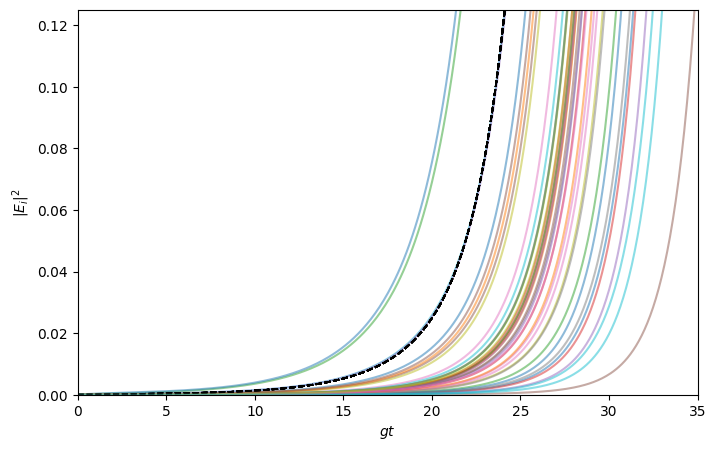

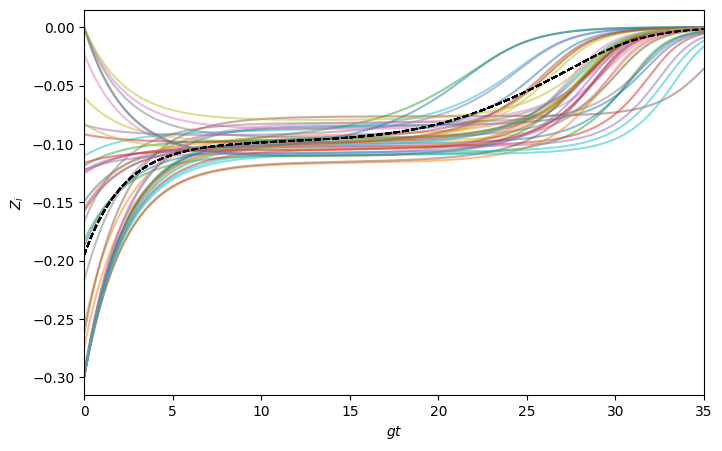

In [ ]:
SEED = 30
rng = np.random.default_rng(SEED)

sigma0 = np.clip(rng.normal(-0.1, 0.01, N), -1, 1)
params = (0.4, 0.6, 0.05/0.4, 0.07/0.4, sigma0)
T, Nt = 2000, 10000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.2, 0.2, N), -0.3, 0)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_fields(J=-0.03j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, E2_mod[i], alpha=0.5); plt.plot(params[0]*t, E2_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$|E_i|^2$'); plt.title('');
plt.xlim(0, 35)
plt.ylim(0, 0.125)
plt.show()

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_fields(J=-0.03j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, sigma_t[i], alpha=0.5); plt.plot(params[0]*t, Z_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$Z_i$'); plt.title('');
plt.xlim(0, 35)
plt.show()